# Xây dựng và đánh giá mô hình AdaBoost trên bộ dữ liệu Breast Cancer Wisconsin

Notebook này trình bày toàn bộ quy trình xây dựng mô hình **AdaBoost từ đầu (from scratch)** và so sánh với **AdaBoostClassifier của sklearn** trên bài toán phân loại ung thư vú.

## Mục tiêu
- Khám phá và làm sạch dữ liệu.
- Tiền xử lý dữ liệu và chuẩn bị tập huấn luyện/kiểm tra.
- Cài đặt thuật toán AdaBoost thủ công.
- Huấn luyện, dự đoán và so sánh với mô hình từ thư viện sklearn.
- Trực quan hóa quá trình học để hiểu sâu hơn cơ chế của AdaBoost.


In [1123]:
import pandas as pd
import numpy as np

In [1124]:
df = pd.read_csv("Data/data.csv")

In [1125]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [1126]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [1127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 1. Làm sạch dữ liệu

Ở bước này, dữ liệu được kiểm tra các giá trị thiếu và loại bỏ những cột không cần thiết cho mô hình.


In [1128]:
df.isnull().sum().sort_values(ascending = False)

Unnamed: 32                569
id                           0
diagnosis                    0
texture_mean                 0
radius_mean                  0
area_mean                    0
smoothness_mean              0
compactness_mean             0
perimeter_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
concavity_mean               0
smoothness_se                0
compactness_se               0
concave points_se            0
concavity_se                 0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
symmetry_se                  0
perimeter_worst              0
area_worst                   0
compactness_worst            0
smoothness_worst             0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_

In [1129]:
df.drop(columns = ['id','Unnamed: 32'],axis = 1,inplace = True)

In [1130]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

## 2. Tiền xử lý dữ liệu

Phần này thực hiện:
- kiểm tra kiểu dữ liệu của biến mục tiêu,
- khảo sát phân bố nhãn,
- mã hóa nhãn sang dạng số để phù hợp với mô hình học máy.


In [1131]:
df['diagnosis'].dtype 

dtype('O')

In [1132]:
df['diagnosis'].value_counts(normalize =True)

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

### 2.1. Mã hóa biến mục tiêu `diagnosis`

Biến `diagnosis` ban đầu có hai giá trị:
- `B` (Benign): khối u lành tính
- `M` (Malignant): khối u ác tính

Trong notebook này, biến được ánh xạ thành:
- `0` → lành tính
- `1` → ác tính


In [1133]:
df['diagnosis'] = df['diagnosis'].map({'B': 0 , 'M':1})

In [1134]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23892\103062696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df,palette='magma')


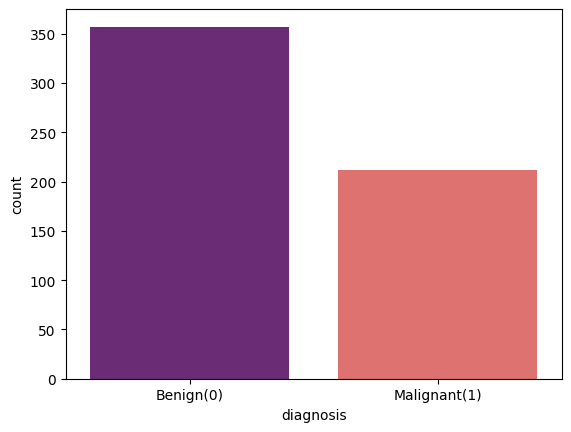

In [1135]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="diagnosis", data=df,palette='magma')
plt.xticks([0,1], ["Benign(0)", "Malignant(1)"])
plt.show()

## 3. Trực quan hóa dữ liệu

Phần này dùng các biểu đồ để quan sát mối quan hệ giữa các đặc trưng, từ đó có cái nhìn trực quan về khả năng phân tách giữa hai lớp.


<Axes: >

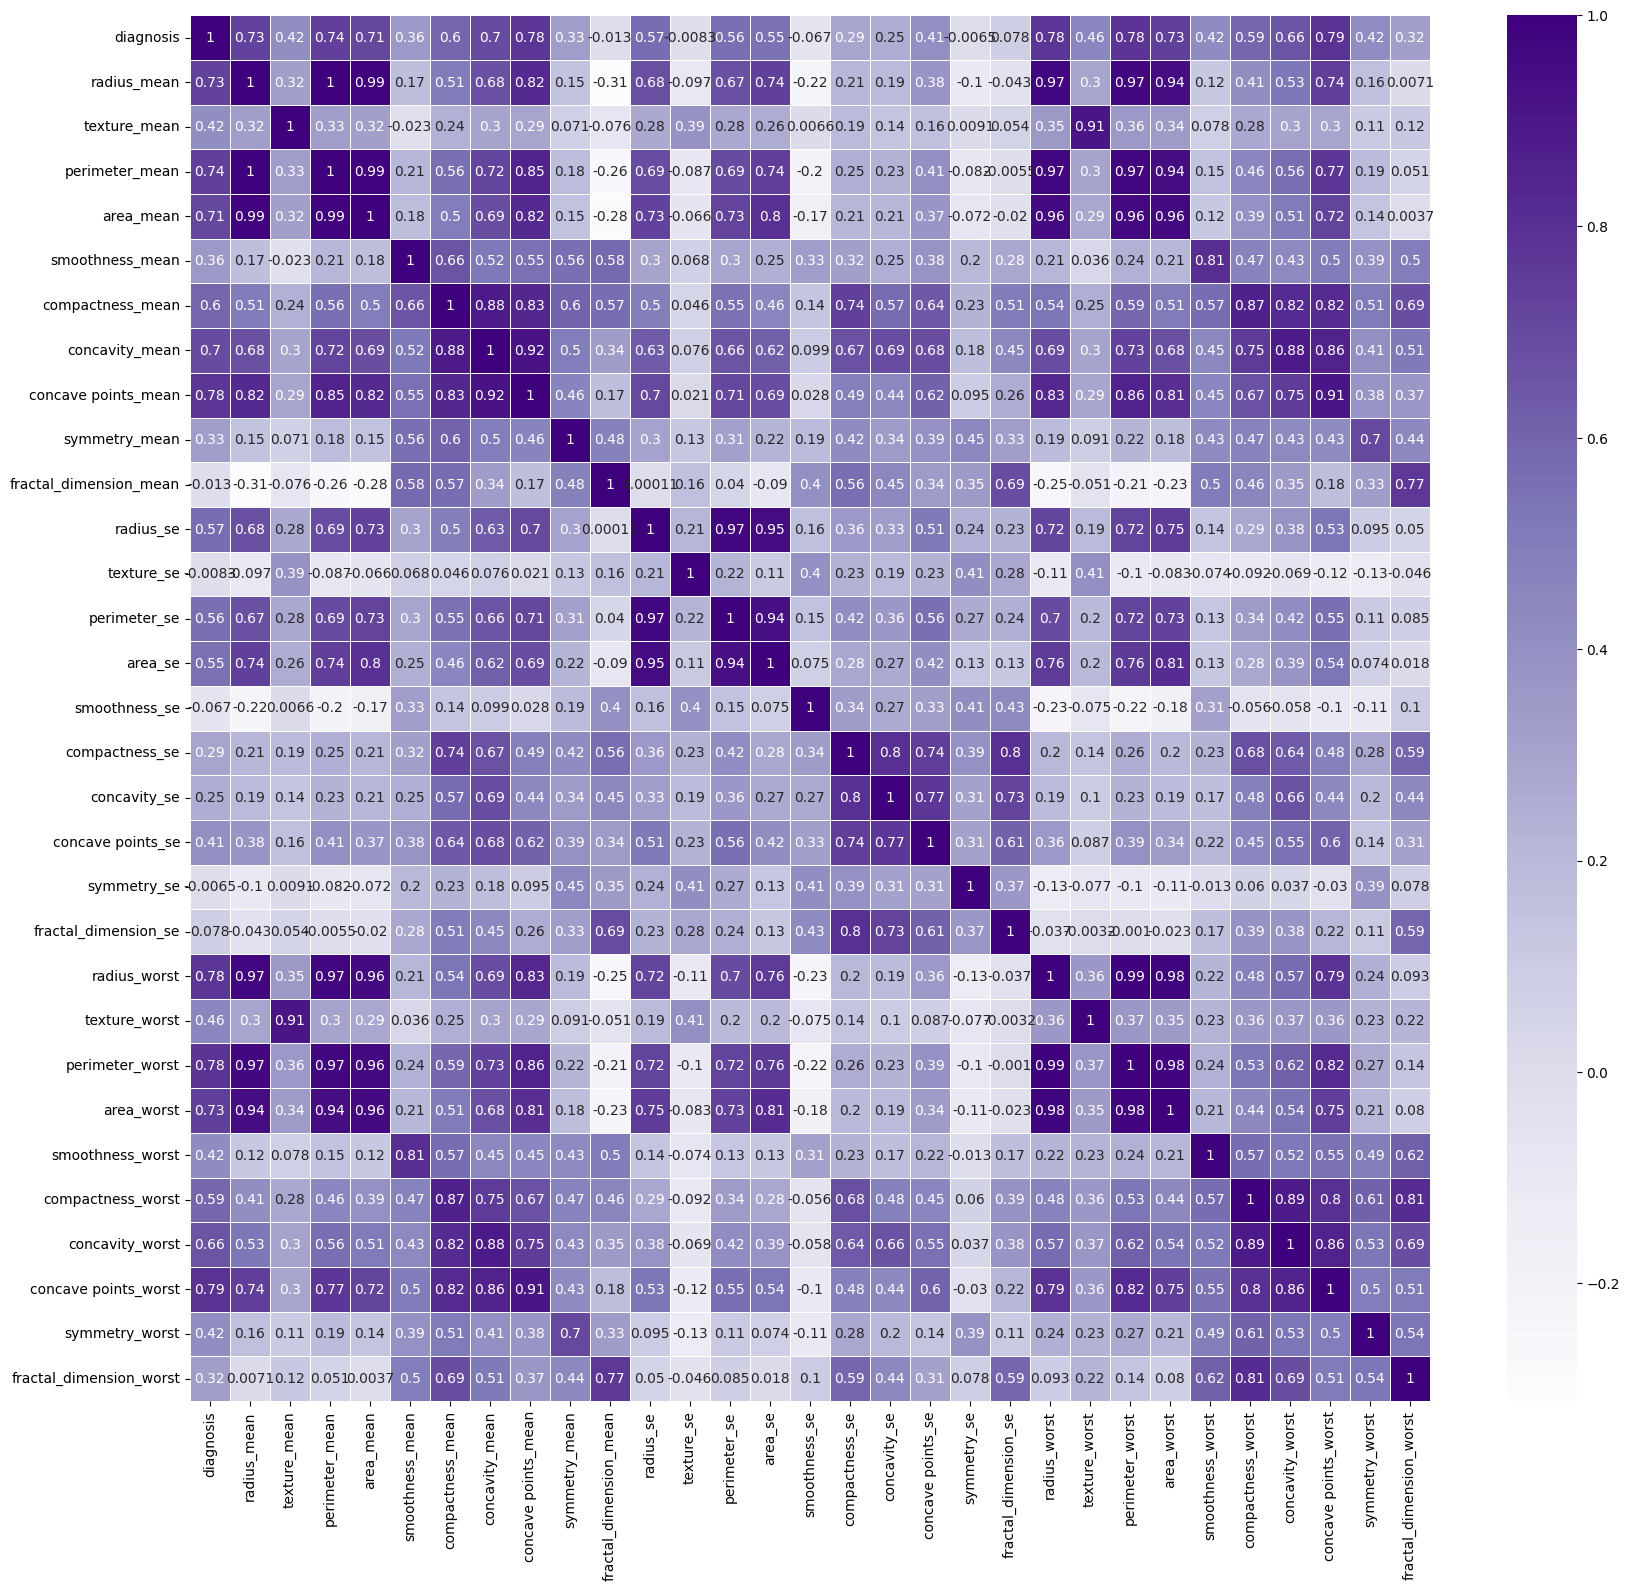

In [1136]:
plt.figure(figsize=(20,18))
sns.heatmap(df.corr(), annot=True,linewidths=.5, cmap="Purples")

In [1137]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

## 4. Chia dữ liệu và chuẩn bị cho mô hình

Dữ liệu được tách thành:
- `X`: tập đặc trưng đầu vào
- `y`: biến mục tiêu

Sau đó chia thành tập huấn luyện và tập kiểm tra để phục vụ quá trình đánh giá mô hình.


In [1138]:
X = df.drop('diagnosis',axis = 1)
y = df['diagnosis']

In [1139]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [1140]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [1141]:
X_train.shape

(455, 30)

In [1142]:
X_test.shape

(114, 30)

## 5. Huấn luyện mô hình

Phần này cài đặt và huấn luyện:
- mô hình **AdaBoost tự xây dựng**
- mô hình **AdaBoostClassifier của sklearn**

Mục tiêu là so sánh kết quả dự đoán và kiểm tra mức độ tương đồng giữa hai cách triển khai.


In [1143]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Helper functions
def compute_error(y, y_pred, w_i):
    '''
    Calculate the error rate of a weak classifier m. Arguments:
    y: actual target value
    y_pred: predicted value by weak classifier
    w_i: individual weights for each observation


    Note that all arrays should be the same length
    '''

    return (np.sum(w_i * (np.not_equal(y, y_pred)).astype(int)))/np.sum(w_i)

def compute_alpha(error):
    '''
    Calculate the weight of a weak classifier m in the majority vote of the final classifier. This is called
    alpha in chapter 10.1 of The Elements of Statistical Learning. Arguments:
    error: error rate from weak classifier m
    '''
    epsilon = 1e-10
    return 0.5 * np.log((1 - error + epsilon) / (error + epsilon))

def update_weights_formular1(w_i, alpha, y, y_pred):
    result = w_i * np.exp(-alpha * y * y_pred)
    w_norm = result / np.sum(result)
    return w_norm


def update_weights_formular2(w_i, alpha, y, y_pred):
    result = np.where(
        y == y_pred,
        w_i * np.exp(-alpha),
        w_i * np.exp(alpha)
    )
    return result / np.sum(result)

# Define AdaBoost class
class AIVNAdaBoost:

    def __init__(self):
        # self.w_i = None
        self.alphas = []
        self.G_M = []
        self.M = None
        self.training_errors = []
        self.prediction_errors = []

    def fit(self, X, y, M = 100):
        '''
        Fit model. Arguments:
        X: independent variables
        y: target variable
        M: number of boosting rounds. Default is 100
        '''

        # Clear before calling
        self.alphas = []
        self.training_errors = []
        self.M = M
        self.G_M = [] 
        self.weight_history = []

        # Iterate over M weak classifiers
        for m in range(0, M):

            # Set weights for current boosting iteration
            if m == 0:
                w_i = np.ones(len(y)) * 1 / len(y)  # At m = 0, weights are all the same and equal to 1 / N
            else:
                 w_i = update_weights_formular2(w_i, alpha_m, y, y_pred)
                # w_i = update_weights_formular1(w_i, alpha_m, y, y_pred)
            # print(w_i)

            # (a) Fit weak classifier and predict labels
            G_m = DecisionTreeClassifier(max_depth = 1)     # Stump: Two terminal-node classification tree
            G_m.fit(X, y, sample_weight = w_i)
            y_pred = G_m.predict(X)

            self.G_M.append(G_m) # Save to list of weak classifiers

            # (b) Compute error
            error_m = compute_error(y, y_pred, w_i)
            self.training_errors.append(error_m)
            # print(error_m)

            # (c) Compute alpha
            alpha_m = compute_alpha(error_m)
            self.alphas.append(alpha_m)
            # print(alpha_m)
            
            self.weight_history.append(w_i.copy())
        assert len(self.G_M) == len(self.alphas)


    def predict1(self, X):
        '''
        Predict using fitted model. Arguments:
        X: independent variables
        '''

        # Initialise dataframe with weak predictions for each observation
        weak_preds = pd.DataFrame(index = range(len(X)), columns = range(self.M))

        # Predict class label for each weak classifier, weighted by alpha_m
        for m in range(self.M):
            y_pred_m = self.G_M[m].predict(X) * self.alphas[m]
            #weak_preds.iloc[:,m] = y_pred_m
            weak_preds[weak_preds.columns[m]] = y_pred_m

        # Estimate final predictions
        y_pred = (1 * np.sign(weak_preds.T.sum())).astype(int)

        return y_pred
    
    def predict2(self, X):
        n_samples = len(X)
        
        score_0 = np.zeros(n_samples)
        score_1 = np.zeros(n_samples)

        for m in range(self.M):
            y_pred_m = self.G_M[m].predict(X)

            score_1 += self.alphas[m] * (y_pred_m == 1)
            score_0 += self.alphas[m] * (y_pred_m == 0)

        y_pred = np.where(score_1 > score_0, 1, 0)

        return y_pred

    def error_rates(self, X, y):
        '''
        Get the error rates of each weak classifier. Arguments:
        X: independent variables
        y: target variables associated to X
        '''

        self.prediction_errors = [] # Clear before calling

        # Predict class label for each weak classifier
        for m in range(self.M):
            y_pred_m = self.G_M[m].predict(X)
            error_m = compute_error(y = y, y_pred = y_pred_m, w_i = np.ones(len(y)))
            self.prediction_errors.append(error_m)

### 5.1. Huấn luyện và dự đoán với mô hình AdaBoost tự xây dựng

Mô hình được huấn luyện trên tập train và đánh giá trên tập test. Với dữ liệu nhãn `0/1`, quá trình tổng hợp dự đoán cuối cùng sử dụng cơ chế bỏ phiếu có trọng số phù hợp với bài toán nhị phân.


In [1144]:
# Fit model
ab = AIVNAdaBoost()
ab.fit(X_train, y_train, M = 50)

# Predict on test set
y_pred = ab.predict2(X_test)
print('The accuracy_score of the model is:', round(accuracy_score(y_test, y_pred), 8))

The accuracy_score of the model is: 0.98245614


### 5.2. Huấn luyện và dự đoán với mô hình AdaBoost của sklearn

Phần này sử dụng `AdaBoostClassifier` từ sklearn làm mốc tham chiếu để so sánh với mô hình tự cài đặt.


In [1145]:
from sklearn.ensemble import AdaBoostClassifier

ab_sk = AdaBoostClassifier(n_estimators = 50)
ab_sk.fit(X_train, y_train)
y_pred_sk = ab_sk.predict(X_test)
print('The accuracy_score of the model is:', round(accuracy_score(y_test, y_pred_sk), 8))

The accuracy_score of the model is: 0.98245614


In [1146]:
print("=== Custom AdaBoost ===")
print(classification_report(y_test, y_pred_custom))

print("=== Sklearn AdaBoost ===")
print(classification_report(y_test, y_pred_sk))

=== Custom AdaBoost ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

=== Sklearn AdaBoost ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [1147]:
np.mean(y_pred == y_pred_sk)

np.float64(1.0)

In [1148]:
np.sum(y_pred != y_pred_sk)

np.int64(0)

## 6. Chuẩn bị các hàm hỗ trợ cho trực quan hóa

Để đánh giá mô hình sâu hơn, notebook bổ sung một số hàm hỗ trợ nhằm:
- theo dõi dự đoán theo từng boosting round,
- tính toán các độ đo như entropy,
- vẽ biểu đồ so sánh giữa mô hình tự xây dựng và sklearn.


In [1149]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    zero_one_loss
)


rounds = list(range(1, 51))
custom_test_acc = []

for m in rounds:
    model = AIVNAdaBoost()
    model.fit(X_train, y_train, M=m)
    pred = model.predict2(X_test)
    custom_test_acc.append(accuracy_score(y_test, pred))

#####################################################################
sk_test_acc = []

for m in rounds:
    model_sk = AdaBoostClassifier(n_estimators=m, random_state=42)
    model_sk.fit(X_train, y_train)
    pred_sk = model_sk.predict(X_test)
    sk_test_acc.append(accuracy_score(y_test, pred_sk))

#####################################################################

def entropy(w):
    w = np.array(w) + 1e-10
    return -np.sum(w * np.log(w))

entropies = [entropy(w) for w in ab.weight_history]

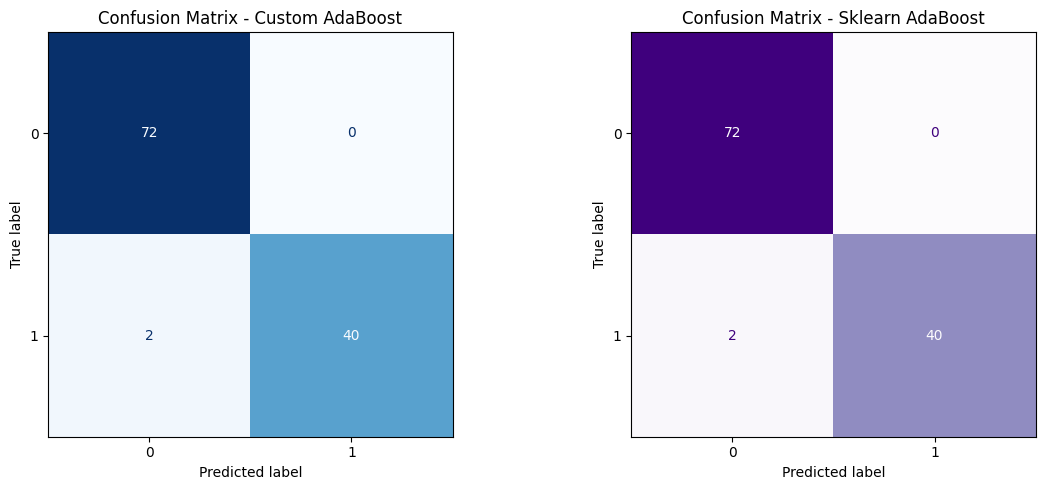

In [1150]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_custom = confusion_matrix(y_test, y_pred)
cm_sk = confusion_matrix(y_test, y_pred_sk)

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_custom)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - Custom AdaBoost')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_sk)
disp2.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title('Confusion Matrix - Sklearn AdaBoost')

plt.tight_layout()
plt.show()

### 6.1. Phân tích confusion matrix

Kết quả cho thấy mô hình đạt độ chính xác cao và **không tạo ra false positive**, tuy nhiên vẫn còn một số **false negative**. Trong bối cảnh bài toán y tế, việc giảm false negative là rất quan trọng vì đây là các trường hợp ung thư bị bỏ sót.


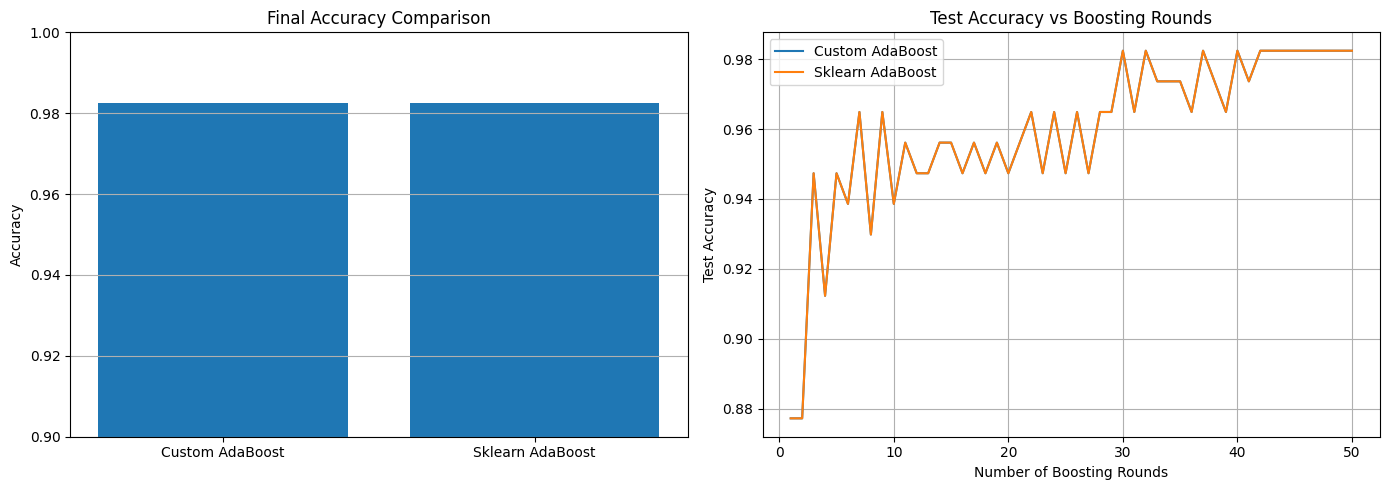

In [1151]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
models = ['Custom AdaBoost', 'Sklearn AdaBoost']
scores = [acc_custom, acc_sk]


axes[0].bar(models, scores)
axes[0].set_ylim(0.9, 1.0)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Final Accuracy Comparison')
axes[0].grid(True, axis='y')

# Plot 2: Accuracy vs boosting rounds
axes[1].plot(rounds, custom_test_acc, label='Custom AdaBoost')
axes[1].plot(rounds, sk_test_acc, label='Sklearn AdaBoost')
axes[1].set_xlabel('Number of Boosting Rounds')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy vs Boosting Rounds')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 6.2. Phân tích accuracy theo số vòng boosting

Biểu đồ cho thấy độ chính xác tăng nhanh trong các vòng boosting đầu tiên và dần ổn định sau khoảng 30 vòng. Hai mô hình (tự cài đặt và sklearn) có xu hướng hội tụ gần như trùng khớp, cho thấy việc cài đặt thuật toán là chính xác và hiệu quả.


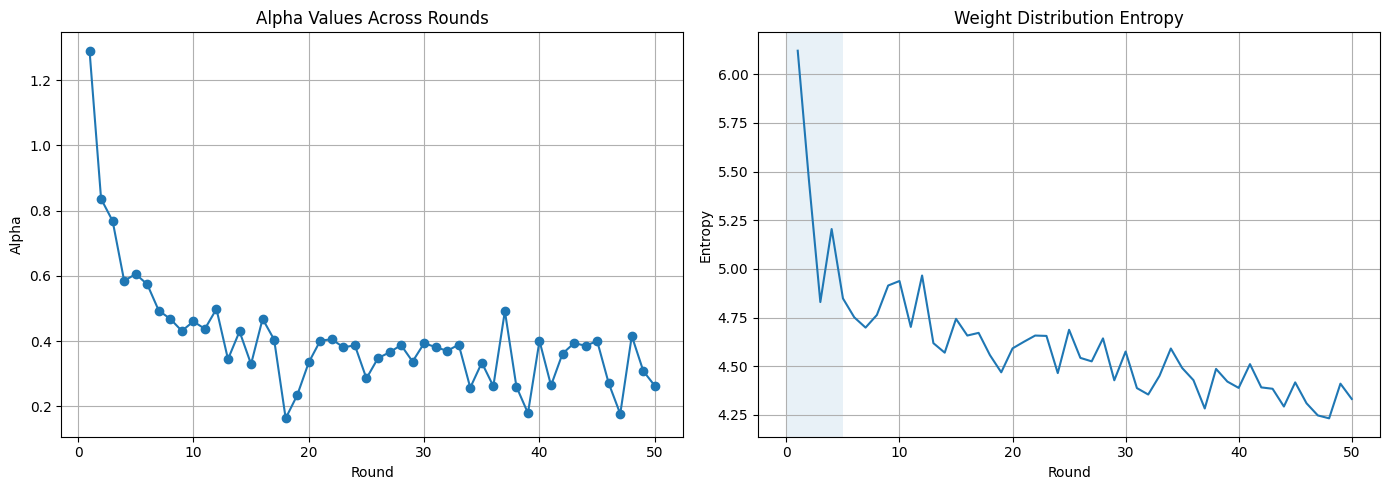

In [1152]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 5: Alpha values
axes[0].plot(range(1, len(ab.alphas) + 1), ab.alphas, marker='o')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Alpha')
axes[0].set_title('Alpha Values Across Rounds')
axes[0].grid(True)

# Plot 6: Entropy
axes[1].plot(range(1, len(entropies) + 1), entropies)
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Entropy')
axes[1].set_title('Weight Distribution Entropy')
axes[1].grid(True)

plt.axvspan(0, 5, alpha=0.1)

plt.tight_layout()
plt.show()

### 6.3. Phân tích alpha và entropy

Biểu đồ **alpha** cho thấy các weak learner đầu tiên có đóng góp lớn nhất vào mô hình, trong khi các learner về sau chủ yếu đóng vai trò tinh chỉnh.

Biểu đồ **entropy** giảm dần chứng tỏ AdaBoost ngày càng tập trung vào các mẫu khó, phản ánh đúng cơ chế cập nhật trọng số của thuật toán.


## 7. Kết luận

Từ các kết quả thực nghiệm có thể rút ra rằng:

- Mô hình **AdaBoost tự xây dựng** đạt hiệu quả tương đương với **AdaBoost của sklearn**.
- Các dự đoán trên tập kiểm tra gần như trùng khớp hoàn toàn giữa hai mô hình.
- Các biểu đồ về accuracy, confusion matrix, alpha và entropy đều cho thấy quá trình huấn luyện bám sát đúng bản chất của AdaBoost.

Nhìn chung, notebook không chỉ cho thấy mô hình hoạt động tốt trên dữ liệu thực tế mà còn giúp giải thích rõ cơ chế học của AdaBoost thông qua các trực quan hóa.
